|<h2>Course:</h2>|<h1><a href="https://udemy.com/course/deeplearning_x/?couponCode=202508" target="_blank">A deep understanding of deep learning</a></h1>|
|-|:-:|
|<h2>Section:</h2>|<h1>FFNs<h1>|
|<h2>Lecture:</h2>|<h1><b>FFN to classify digits<b></h1>|

<br>

<h5><b>Teacher:</b> Mike X Cohen, <a href="https://sincxpress.com" target="_blank">sincxpress.com</a></h5>
<h5><b>Course URL:</b> <a href="https://udemy.com/course/deeplearning_x/?couponCode=202508" target="_blank">udemy.com/course/deeplearning_x/?couponCode=202508</a></h5>
<i>Using the code without the course may lead to confusion or errors.</i>

In [1]:
# import libraries
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader,TensorDataset
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline

from torchvision import datasets

matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

# Setup GPU

# Import and process the data

In [2]:
# download MNIST dataset
output_dir = 'sample_data'
mnist = datasets.MNIST(root='sample_data', download=True)

# extract labels (number IDs) and data
labels = mnist.targets.numpy()
data = mnist.data.numpy().reshape(mnist.data.shape[0], -1)  # flatten to 2D

print(labels.shape)
print(data.shape)

(60000,)
(60000, 784)


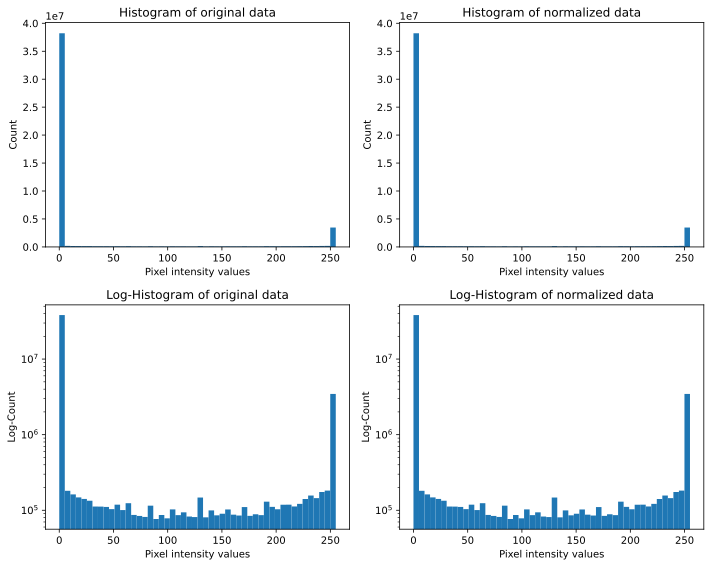

In [3]:
dataNorm = data.copy()

fig,ax = plt.subplots(2,2,figsize=(10,8))
ax[0,0].hist(data.flatten(),50)
ax[0,0].set_xlabel('Pixel intensity values')
ax[0,0].set_ylabel('Count')
ax[0,0].set_title('Histogram of original data')

ax[1,0].hist(data.flatten(),50)
ax[1,0].set_xlabel('Pixel intensity values')
ax[1,0].set_ylabel('Log-Count')
ax[1,0].set_yscale('log')
ax[1,0].set_title('Log-Histogram of original data')

ax[0,1].hist(dataNorm.flatten(),50)
ax[0,1].set_xlabel('Pixel intensity values')
ax[0,1].set_ylabel('Count')
ax[0,1].set_title('Histogram of normalized data')

ax[1,1].hist(dataNorm.flatten(),50)
ax[1,1].set_xlabel('Pixel intensity values')
ax[1,1].set_ylabel('Log-Count')
ax[1,1].set_yscale('log')
ax[1,1].set_title('Log-Histogram of normalized data')

fig.tight_layout()
plt.show()

# Create train/test groups using DataLoader

In [4]:
def split_train_test(scale_train: bool = False, scale_test: bool = False):
    # Step 1: convert to tensor
    dataT   = torch.tensor( dataNorm ).float()
    labelsT = torch.tensor( labels ).long() # long = int64

    # Step 2: use scikitlearn to split the data
    train_data,test_data, train_labels,test_labels = train_test_split(dataT, labelsT, test_size=.1)

    str_min_max = lambda name,x: f'{name}: min: {torch.min(x)} max: {torch.max(x)}'
    scale_min_max = lambda x: (x - torch.min(x)) / (torch.max(x) - torch.min(x))

    # Step 2.1: Normalize train_data to 0 and 1
    if scale_train:
        train_data = scale_min_max(train_data)
    print(str_min_max('Train Data', train_data))

    # Step 2.2: Normalize test_data to 0 and 1
    if scale_test:
        test_data = scale_min_max(test_data)
    print(str_min_max('Test Data', test_data))

    # Step 3: convert into PyTorch Datasets
    train_data = TensorDataset(train_data,train_labels)
    test_data  = TensorDataset(test_data,test_labels)

    # Step 4: translate into dataloader objects
    batchsize    = 32
    train_loader = DataLoader(train_data,batch_size=batchsize,shuffle=True,drop_last=True)
    test_loader  = DataLoader(test_data,batch_size=test_data.tensors[0].shape[0])
    return train_loader,test_loader

train_loader,test_loader = split_train_test()

Train Data: min: 0.0 max: 255.0
Test Data: min: 0.0 max: 255.0


In [5]:
# check all variables in workspace
%whos

Variable            Type          Data/Info
-------------------------------------------
DataLoader          type          <class 'torch.utils.data.dataloader.DataLoader'>
F                   module        <module 'torch.nn.functio<...>/torch/nn/functional.py'>
TensorDataset       type          <class 'torch.utils.data.dataset.TensorDataset'>
ax                  ndarray       2x2: 4 elems, type `object`, 32 bytes
data                ndarray       60000x784: 47040000 elems, type `uint8`, 47040000 bytes (44.86083984375 Mb)
dataNorm            ndarray       60000x784: 47040000 elems, type `uint8`, 47040000 bytes (44.86083984375 Mb)
datasets            module        <module 'torchvision.data<...>on/datasets/__init__.py'>
fig                 Figure        Figure(1000x800)
labels              ndarray       60000: 60000 elems, type `int64`, 480000 bytes (468.75 kb)
matplotlib_inline   module        <module 'matplotlib_inlin<...>tlib_inline/__init__.py'>
mnist               MNIST         Datase

# Create the DL model

In [6]:
# create a class for the model
def createTheMNISTNet():

  class mnistNet(nn.Module):
    def __init__(self):
      super().__init__()

      ### input layer
      self.input = nn.Linear(784,64)

      ### hidden layer
      self.fc1 = nn.Linear(64,32)
      self.fc2 = nn.Linear(32,32)

      ### output layer
      self.output = nn.Linear(32,10)

    # forward pass
    def forward(self,x):
      x = F.relu( self.input(x) )
      x = F.relu( self.fc1(x) )
      x = F.relu( self.fc2(x) )
      return torch.log_softmax( self.output(x),axis=1 )
      # NEW HERE: log-softmax the output, because I'm using NLLLoss instead of CrossEntropyLoss

  # create the model instance
  net = mnistNet()

  # loss function
  lossfun = nn.NLLLoss()

  # optimizer
  optimizer = torch.optim.Adam(net.parameters(),lr=.01)

  return net,lossfun,optimizer

In [7]:
# test the model with one batch
net,lossfun,optimizer = createTheMNISTNet()

X,y = next(iter(train_loader))
yHat = net(X)

# values are log-probability of each number (0-9)
# print(torch.exp(yHat))

# now let's compute the loss
loss = lossfun(yHat,y)
print(' ')
print('Loss:')
print(loss)

 
Loss:
tensor(7.7682, grad_fn=<NllLossBackward0>)


# Create a function that trains the model

In [8]:
# a function that trains the model

def function2trainTheModel():

  # number of epochs
  numepochs = 40

  # create a new model
  net,lossfun,optimizer = createTheMNISTNet()

  # initialize losses
  trainLoss    = torch.zeros(numepochs)
  testLoss    = torch.zeros(numepochs)
  trainAcc  = []
  testAcc   = []

  # loop over epochs
  for epochi in range(numepochs):
    
    net.train()  # set the model to training mode

    # loop over training data batches
    batchAcc  = []
    batchLoss = []
    for X,y in train_loader:

      # forward pass and loss
      yHat = net(X)
      loss = lossfun(yHat,y)

      # backprop
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      # loss from this batch
      batchLoss.append(loss.item())

      # compute accuracy
      matches = torch.argmax(yHat,axis=1) == y     # booleans (false/true)
      matchesNumeric = matches.float()             # convert to numbers (0/1)
      accuracyPct = 100*torch.mean(matchesNumeric) # average and x100
      batchAcc.append( accuracyPct )               # add to list of accuracies
    # end of batch loop...

    # now that we've trained through the batches, get their average training accuracy
    trainAcc.append( torch.mean(torch.tensor(batchAcc) ) )

    # and get average losses across the batches
    trainLoss[epochi] = np.mean(batchLoss)

    # test accuracy
    net.eval()  # set the model to evaluation mode
    X,y = next(iter(test_loader)) # extract X,y from test dataloader
    with torch.no_grad():  # no need to track gradients
      yHat = net(X)
      # compare the following really long line of code to the training accuracy lines
      testAcc.append( 100*torch.mean((torch.argmax(yHat,axis=1)==y).float()) )
      testLoss[epochi] = lossfun(yHat,y).item()

  # end epochs

  # function output
  return trainAcc,testAcc,trainLoss,testLoss,net


# Run the model and show the results!


Scenario: scale: train & test
Train Data: min: 0.0 max: 1.0
Test Data: min: 0.0 max: 1.0

Scenario: scale: train
Train Data: min: 0.0 max: 1.0
Test Data: min: 0.0 max: 255.0

Scenario: scale: test
Train Data: min: 0.0 max: 255.0
Test Data: min: 0.0 max: 1.0


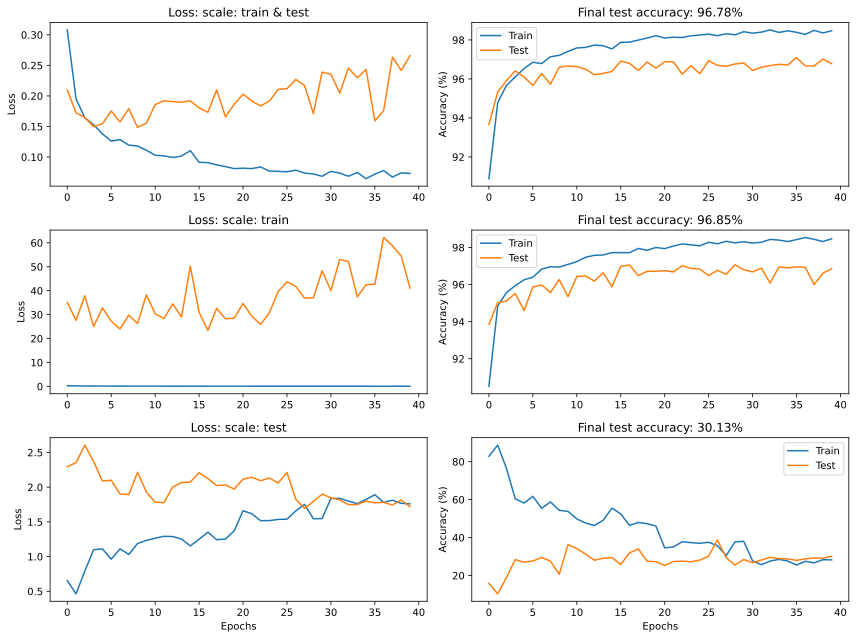

In [9]:
fig,ax = plt.subplots(3,2,figsize=(12,9))

scenarios_d = {'scale: train & test': (True, True), 'scale: train': (True, False), 'scale: test': (False, True)}

for i,(s,sv) in enumerate(scenarios_d.items()):
    print(f'\nScenario: {s}')
    train_loader,test_loader = split_train_test(sv[0], sv[1])
    trainAcc,testAcc,trainLoss,testLoss,net = function2trainTheModel()

    ax[i,0].plot(trainLoss,label='Train')
    ax[i,0].plot(testLoss,label='Test')
    ax[i,0].set_ylabel('Loss')
    ax[i,0].set_title(f'Loss: {s}')
    
    ax[i,1].plot(trainAcc,label='Train')
    ax[i,1].plot(testAcc,label='Test')
    ax[i,1].set_ylabel('Accuracy (%)')
    ax[i,1].set_title(f'Final test accuracy: {testAcc[-1]:.2f}%')
    ax[i,1].legend()
    
ax[-1,0].set_xlabel('Epochs')
ax[-1,1].set_xlabel('Epochs')

fig.tight_layout()
plt.show()

# Inspect the results in more detail

In [10]:
# run the model through for the test data
X,y = next(iter(test_loader))
predictions = net(X).detach()

predictions

tensor([[-5.4464, -5.1800, -1.1226,  ..., -2.8802, -2.1606, -3.0016],
        [-5.3332, -5.1004, -1.1222,  ..., -2.7390, -2.1179, -2.8591],
        [-1.4583, -1.3592, -3.0717,  ..., -4.6821, -1.9424, -4.7826],
        ...,
        [-5.4464, -5.1800, -1.1226,  ..., -2.8802, -2.1606, -3.0016],
        [-4.7538, -5.3364, -3.2818,  ..., -1.4808, -3.2503, -1.5695],
        [-5.4464, -5.1800, -1.1226,  ..., -2.8802, -2.1606, -3.0016]])

/tmp/ipykernel_1109/1990962932.py:4: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  plt.bar(range(10),np.exp(predictions[sample2show])) # try adding exp!


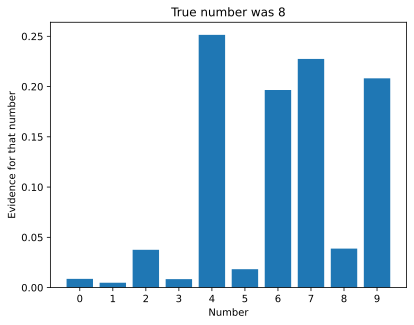

In [11]:
# Evidence for all numbers from one sample
sample2show = 10

plt.bar(range(10),np.exp(predictions[sample2show])) # try adding exp!
plt.xticks(range(10))
plt.xlabel('Number')
plt.ylabel('Evidence for that number')
plt.title('True number was %s' %y[sample2show].item())
plt.show()

[   1    2    3 ... 5995 5996 5997]


/tmp/ipykernel_1109/1915953787.py:10: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  ax[0].bar(range(10),np.exp(predictions[errors[sample2show]]))


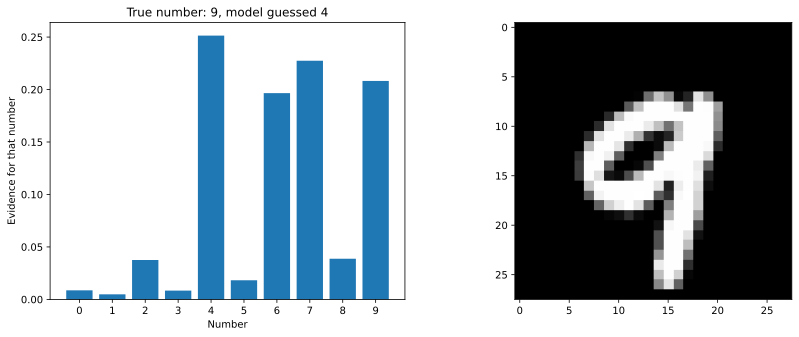

In [12]:
# find the errors
errors = np.where( torch.max(predictions,axis=1)[1] != y )[0]
print(errors)

# Evidence for all numbers from one sample
sample2show = 10

fig,ax = plt.subplots(1,2,figsize=(14,5))

ax[0].bar(range(10),np.exp(predictions[errors[sample2show]]))
ax[0].set_xticks(range(10))
ax[0].set_xlabel('Number')
ax[0].set_ylabel('Evidence for that number')
ax[0].set_title('True number: %s, model guessed %s'
                %( y[errors[sample2show]].item(), torch.argmax(predictions[errors[sample2show]]).item() ))

ax[1].imshow( np.reshape(X[errors[sample2show],:],(28,28)) ,cmap='gray')

plt.show()

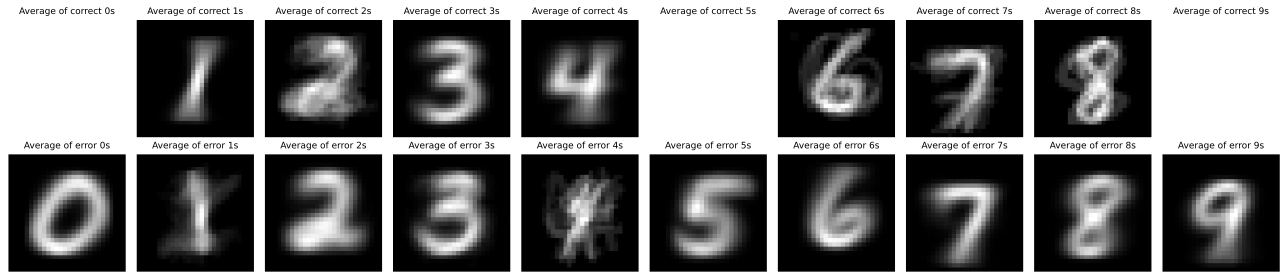

In [16]:
# 1) Average together the correct 7's and the error 7's, and make images of them (that is, one image
#    of all correct 7's and one image of all incorrectly labeled 7's). How do they look?
# Answer: The averaged correct 7's are more concentrated around typical shape of true 7, while the averaged wrong 7's are more diffused and less defined.
# 2) Repeat #1 for all numbers to produce a 2x10 matrix of images with corrects on top
#    and errors on the bottom.

# Run the model:
X,y = next(iter(test_loader))
predictions = net(X).detach()

correctPredictionsIdxs = np.argwhere(torch.max(predictions,axis=1)[1] == y)[0]
correctPredictedData = X[correctPredictionsIdxs,:]
correctPredictedLabels = y[correctPredictionsIdxs]

wrongPredictionsIdxs = np.argwhere(torch.max(predictions,axis=1)[1] != y)[0]
wrongPredictedData = X[wrongPredictionsIdxs,:]
wrongPredictedLabels = y[wrongPredictionsIdxs]

fig,axs = plt.subplots(2,10,figsize=(18,4))
imDim = (28,28)
for i in range(10):
    correctIdxs = np.argwhere(correctPredictedLabels == i)[0]
    errorIdxs = np.argwhere(wrongPredictedLabels == i)[0]

    avgCorrectNums = np.reshape(torch.mean(correctPredictedData[correctIdxs], axis=0), imDim)
    avgErrorNums = np.reshape(torch.mean(wrongPredictedData[errorIdxs], axis=0), imDim)

    axs[0,i].imshow(avgCorrectNums,cmap='gray')
    axs[0,i].title.set_text(f'Average of correct {i}s')
    axs[0,i].axis('off')
    axs[1,i].imshow(avgErrorNums,cmap='gray')
    axs[1,i].title.set_text(f'Average of error {i}s')
    axs[1,i].axis('off')

for ax in axs.flat:
    ax.title.set_fontsize(9)
fig.tight_layout()
plt.show()


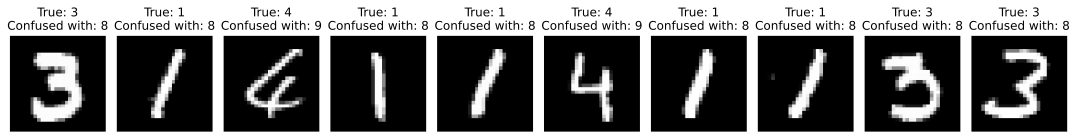

In [14]:
# 3) Identify "almost errors," which we can define as correct categorizations that had a probability of
#    e.g., >.1 for any other number. Make images of some of these numbers. Can you understand why the model
#    was confused?
# Answer: In my opinion the almost errors are occuring due to insufficient hidden layer design.

# Identify "almost errors"
almost_errors = []
almost_errors_labels = []
correctPredictionsIdxs = np.argwhere(torch.max(predictions,axis=1)[1] == y)[0]
otherNumProbabilityThreshold = .1
predictionsProbabilities = torch.exp(predictions)  # convert log-probabilities to probabilities
for idx in correctPredictionsIdxs:
    probs = predictionsProbabilities[idx]
    correct_label = y[idx].item()
    idxThreshold = [i for i in range(10) if probs[i] > otherNumProbabilityThreshold and i != correct_label]
    if len(idxThreshold) > 0:
        almost_errors.append(idx)
        almost_errors_labels.append(np.max(idxThreshold))

# Visualize some "almost errors"
num_to_show = 10
fig, axs = plt.subplots(1, num_to_show, figsize=(15, 5))
for i, idx in enumerate(almost_errors[:num_to_show]):
    axs[i].imshow(X[idx].reshape(28, 28), cmap='gray')
    axs[i].set_title(f'True: {y[idx].item()}\nConfused with: {almost_errors_labels[i]}')
    axs[i].axis('off')

plt.tight_layout()
plt.show()

# Additional explorations

In [15]:
# 1) Average together the correct 7's and the error 7's, and make images of them (that is, one image
#    of all correct 7's and one image of all incorrectly labeled 7's). How do they look?
#
# 2) Repeat #1 for all numbers to produce a 2x10 matrix of images with corrects on top
#    and errors on the bottom.
#
# 3) Identify "almost errors," which we can define as correct categorizations that had a probability of
#    e.g., >.1 for any other number. Make images of some of these numbers. Can you understand why the model
#    was confused?
#
# 4) I didn't use .train(), .eval(), or no_grad() here. Is that a problem? Can you add those in without checking
#    other notebooks?
# added
#